In [ ]:
import numpy as np
from LID_1D import run_1D

durations = ["1ms", "250us"]
max_energies = [1.003, 0.351]

rs = np.linspace(0, 1.5e-3, 50, endpoint=True)

for i, duration in enumerate(durations):
    output_folder = f"./LID_1D_results/results_{duration}_1D/"

    for j in range(0, 21):

        E0 = max_energies[i] * j / 20

        fluxes = np.zeros_like(rs, dtype=np.float64)
        rets_fin = np.zeros_like(rs, dtype=np.float64)

        for k, r in enumerate(rs):
            print(f"Iteration {i}: r={r/1e-3:.2e} mm")

            data = run_1D(E0, r, duration, output_folder)

            flux = -np.array(data[0].data)
            t = np.array(data.t)

            fluxes[k] = np.trapz(flux, x=t)
            retention = np.array(data[1].data)

            rets_fin[k] = retention[-1]

        des = np.trapz(2 * np.pi * rs * fluxes, x=rs)

        export = np.column_stack([rs.transpose(), rets_fin.transpose()])
        header = f"E={E0:.3f},Desorbed={des}"

        np.savetxt(
            output_folder + f"profiles_{duration}_E{E0:.3f}.txt",
            export,
            header=header,
            delimiter=",",
            comments="",
        )

Iteration 0: r=0.00e+00 mm
Defining variational problem heat transfers
Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Time stepping...
100.0 %        1.0e-01 s    Elapsed time so far: 44.3 s
0 4.574082236418101e+21 0.0


## Reconstruction of the temperature field when the peak surface temperature is reached

In [7]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import os
import re


def get_data(folder, field, duration, index):

    merged_data = None

    for filename in sorted(os.listdir(folder)):

        if filename.startswith(f"{field}_{duration}"):
            data = np.loadtxt(folder + filename, skiprows=1, delimiter=",")

            floats_list = re.findall(r"[-+]?(?:\d*\.*\d+)", filename)
            r = np.ones(len(data)) * float(floats_list[-2] + "e" + floats_list[-1])

            combined_data = np.column_stack([r, data[:, 0], data[:, index]])

            if merged_data is None:
                merged_data = combined_data
            else:
                merged_data = np.vstack([merged_data, combined_data])

    return merged_data

In [9]:
folder = "./LID_1D_results/"
duration = "1ms"
index = 1  # 1 - the peak temperature, 2 - the final time

T_data = get_data(folder, "T", duration, 1)

interp = LinearNDInterpolator(
    list(zip(T_data[:, 0], T_data[:, 1])),
    T_data[:, -1].transpose(),
)

r_intrp = np.linspace(0, 1e-3, 500, endpoint=True)
z_intrp = np.linspace(0, 6e-3 + 1e-6, 500)

T_r, T_z = np.meshgrid(r_intrp, z_intrp)  # 2D grid for interpolation

T_field = interp(T_r, T_z)

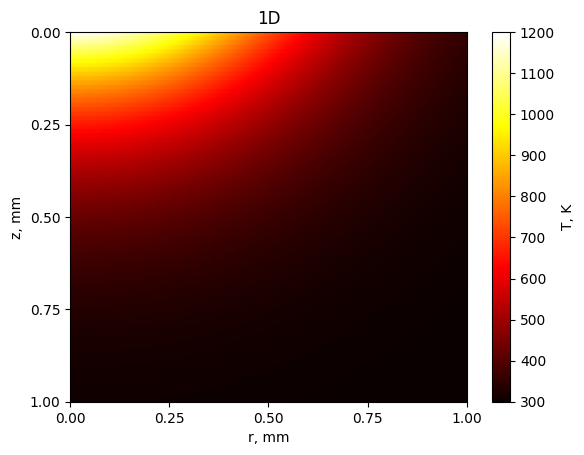

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()

pcm = plt.pcolormesh(
    T_r * 1e3, T_z * 1e3, T_field, shading="gouraud", cmap="hot", vmax=1200, vmin=300
)

fig.colorbar(pcm, orientation="vertical", label=r"T, K")

plt.ylim(1, 0)
plt.ylabel("z, mm")
plt.xlabel("r, mm")
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.title("1D")
plt.show()

In [12]:
folder = "./LID_1D_results/"
duration = "1ms"
index = 2  # 1 - the peak temperature, 2 - the final time

ret_data = get_data(folder, "retention", duration, 2)

interp = LinearNDInterpolator(
    list(zip(ret_data[:, 0], ret_data[:, 1])),
    ret_data[:, -1].transpose(),
)

r_intrp = np.linspace(0, 1e-3, 500, endpoint=True)
z_intrp = np.linspace(0, 1e-6, 500, endpoint=True)

ret_r, ret_z = np.meshgrid(r_intrp, z_intrp)  # 2D grid for interpolation

ret_field = interp(ret_r, ret_z)

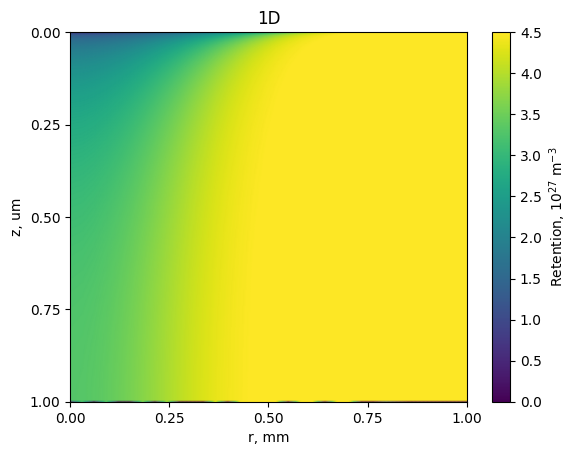

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()

pcm = plt.pcolormesh(
    ret_r * 1e3,
    ret_z * 1e6,
    ret_field / 1e27,
    shading="gouraud",
    cmap="viridis",
    vmax=4.5,
    vmin=0,
)

fig.colorbar(pcm, orientation="vertical", label=r"Retention, $10^{27}$ m$^{-3}$")

plt.ylim(1, 0)
plt.ylabel("z, um")
plt.xlabel("r, mm")
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.title("1D")
plt.show()